# Initial EDA 

In [36]:
from src.data_collection_module import read_data_pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
df = read_data_pd('us_average_prices_monthly.csv')
df.head()

,date,year,month,item,unit,category,price,series_id
0,2015-01-01,2015,1,All Ham (Excluding Canned Ham and Luncheon Sli...,lb. (453.6 gm),"Meat, broad category",3.211,APU0000FD2101
1,2015-02-01,2015,2,All Ham (Excluding Canned Ham and Luncheon Sli...,lb. (453.6 gm),"Meat, broad category",3.221,APU0000FD2101
2,2015-03-01,2015,3,All Ham (Excluding Canned Ham and Luncheon Sli...,lb. (453.6 gm),"Meat, broad category",3.176,APU0000FD2101
3,2015-04-01,2015,4,All Ham (Excluding Canned Ham and Luncheon Sli...,lb. (453.6 gm),"Meat, broad category",2.971,APU0000FD2101
4,2015-05-01,2015,5,All Ham (Excluding Canned Ham and Luncheon Sli...,lb. (453.6 gm),"Meat, broad category",3.045,APU0000FD2101


## 1. Summary statistics for numerical variables

In [38]:
df[['price', 'month', 'year']].describe()

,price,month,year
count,8869.000000,8869.000000,8869.000000
mean,3.585699,6.347503,2020.170369
std,2.521724,3.440797,3.349772
min,0.131000,1.000000,2015.000000
25%,1.621000,3.000000,2017.000000
50%,3.172000,6.000000,2020.000000
75%,4.870000,9.000000,2023.000000
max,14.727000,12.000000,2026.000000


`price` is the only real measurement. Since prices use different units to measure (per lbs, per dozen, per gallon, etc.) the summary mixes them all together.

In [39]:
df.groupby('category')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
Bakery and grains,824.0,1.758067,1.236417,0.356,0.78350,1.3510,2.07725,5.352
Beef,1595.0,6.430275,2.023359,3.547,5.07400,5.8880,7.52750,14.727
Dairy and fats,906.0,3.921938,1.391851,1.043,3.16575,4.0870,4.91050,6.505
Drinks,474.0,4.716951,5.321493,0.326,1.35500,1.7260,12.16900,14.247
Eggs,138.0,2.261688,0.982940,1.203,1.54100,1.9960,2.71425,6.227
Energy,1107.0,2.619874,1.351069,0.131,1.82600,2.7950,3.55400,5.973
Fruit,859.0,1.926383,0.909304,0.544,1.32800,1.9780,2.48100,4.970
"Meat, broad category",407.0,5.353715,1.583181,2.822,4.41150,5.2030,6.75800,9.571
Pantry and snacks,208.0,0.714149,0.147662,0.549,0.62200,0.6520,0.75000,1.054


This is a summary of `price` seperated by `category`.

## 2. Categorical variables

In [40]:
df['category'].value_counts()

category
Beef                    1595
Energy                  1107
Pork and deli            960
Vegetables               916
Dairy and fats           906
Fruit                    859
Bakery and grains        824
Poultry                  475
Drinks                   474
Meat, broad category     407
Pantry and snacks        208
Eggs                     138
Name: count, dtype: int64

In [41]:
df['unit'].value_counts()

unit
lb. (453.6 gm)           6266
gallon/3.785 liters       693
16 oz. (473.2 ml)         276
gal. (3.8 lit)            237
doz.                      138
KWH                       138
gallon (3.785 liters)     138
1/2 gal. (1.9 lit)        138
16 oz.                    138
therm                     138
1 liter (33.8 oz)         138
12 oz. (340.2 gm)         134
2 liters (67.6 oz)         99
12 oz. (354.9 ml)          99
8 oz. (226.8 gm)           99
Name: count, dtype: int64

The most common category is `Beef`, with 1595 rows. The most common unit is `lb`with 6266 rows.

## 3. Summary table

In [42]:
df.groupby('category')['price'].agg(['count', 'mean', 'median', 'min', 'max'])

,count,mean,median,min,max
category,,,,,
Bakery and grains,824,1.758067,1.3510,0.356,5.352
Beef,1595,6.430275,5.8880,3.547,14.727
Dairy and fats,906,3.921938,4.0870,1.043,6.505
Drinks,474,4.716951,1.7260,0.326,14.247
Eggs,138,2.261688,1.9960,1.203,6.227
Energy,1107,2.619874,2.7950,0.131,5.973
Fruit,859,1.926383,1.9780,0.544,4.970
"Meat, broad category",407,5.353715,5.2030,2.822,9.571
Pantry and snacks,208,0.714149,0.6520,0.549,1.054


Categories differ a lot in price level, with `Beef` the most expensive on average and `Pantry and snacks` the cheapest.

## 4. Visualizations

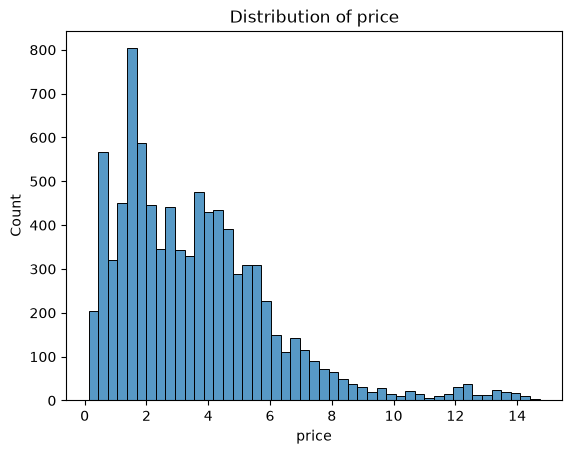

In [43]:
sns.histplot(df['price'])
plt.title('Distribution of price')
plt.show()

Most items are relatively cheap, so the distribution is skewed to the right.

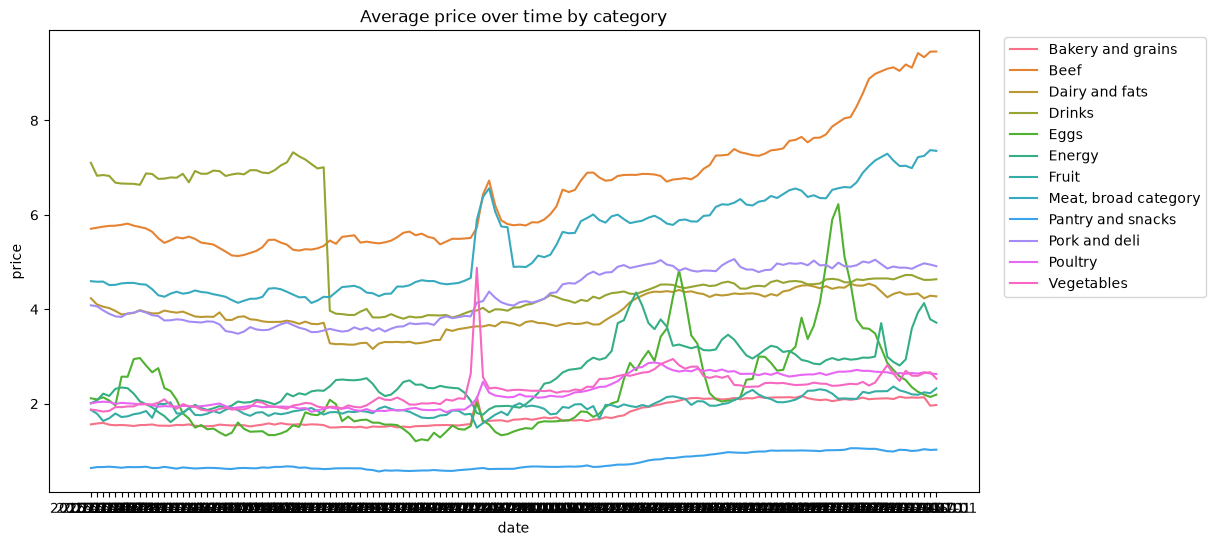

In [44]:
monthly = df.groupby(['date', 'category'])['price'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly, x='date', y='price', hue='category')
plt.title('Average price over time by category')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

Prices in most categories have increased over time, with `Eggs` having the most spikes and drops.